### 📚 Lesson 4.1: Word2Vec – Skip-gram (from scratch)

---

**Mày đã học gì rồi?**

* Mày đã biết: one-hot, BoW, TF-IDF, tokenization.
* Hiểu rằng BoW/TF-IDF không capture ngữ nghĩa → cần Word Embeddings.

---

#### ❓ Today's question

"How can a computer learn word meanings by predicting surrounding words from a given word?"

---

#### 💡 Key ideas

* **Distributional hypothesis**: từ nào xuất hiện trong cùng ngữ cảnh → có ý nghĩa gần nhau.
* **Skip-gram model**:

  * Input: 1 từ trung tâm (center word).
  * Output: các từ ngữ cảnh xung quanh (context words).
  * Ví dụ: `"I love NLP"` với window size = 1:

    * (center=`I`, context=`love`)
    * (center=`love`, context=`I`), (center=`love`, context=`NLP`)
    * (center=`NLP`, context=`love`)
* **Cấu trúc mạng đơn giản**:

  * Input one-hot → hidden layer (embedding matrix) → output softmax (predict context).
  * Embedding chính là weight matrix ở hidden layer.

👉 Ý tưởng: model học embedding vector sao cho nó giỏi predict context.

---

#### 📝 Practice Problem (from scratch)

**Task:**

* Input corpus: (`from .samples import corpus`)
* Step 1: Build vocab
* Step 2: Build training samples (center, context) với window size = 1.
* Step 3: Represent center word bằng one-hot.
* Step 4: Define forward pass: one-hot × embedding matrix → hidden → output (softmax).
* Step 5: Loss = cross-entropy over training samples.
* Step 6: Train step: backprop, update W_in và W_out.
* Step 7: Training loop: run qua epochs, record loss.

👉 Bài tập cho mày bây giờ: **Step 1**.
Hãy viết code tạo ra training pairs `(center, context)` từ corpus trên, window size = 1.

Ví dụ: với `"I love NLP"` → phải ra `[("I","love"), ("love","I"), ("love","NLP"), ("NLP","love")]`.

---

#### 🧩 Solution

In [1]:
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from samples import corpus

In [2]:
# Step 1:
vocabs = list(sorted(set(word for sent in corpus for word in sent.lower().split())))
num_vocabs = len(vocabs)

In [3]:
embed_dim = 100
W_in = np.random.randn(num_vocabs, embed_dim) * 0.01
W_out = np.random.randn(embed_dim, num_vocabs) * 0.01

lr = 0.01
epochs = 2000

In [4]:
# Step 2:
wsize = 1
dataset: list[tuple[str, str]] = []

for sent in corpus:
    words = sent.lower().split()
    dataset.extend(
        (words[i], words[j])
        for i in range(len(words))
        for j in range(max(0, i - wsize), min(len(words), i + wsize + 1))
        if i != j
    )

In [5]:
# Step 3:
word2idx = {word: i for i, word in enumerate(vocabs)}

In [6]:
# Step 4:
def forward(center_word: str):
    logits = W_in[word2idx[center_word]] @ W_out
    logits = logits - logits.max()
    scores = np.exp(logits)
    return scores / scores.sum()

In [7]:
# Step 5:
def loss():
    probs = {word: forward(word) for word in vocabs}
    return sum(
        -np.log(probs[center_word][word2idx[context_word]])
        for center_word, context_word in dataset
    )

In [8]:
# Step 6:
def train_step(center_word: str, context_word: str):
    global W_out

    idx_center = word2idx[center_word]
    idx_context = word2idx[context_word]

    error = forward(center_word)
    error[idx_context] -= 1

    grad_W_out = np.outer(W_in[idx_center], error)
    grad_W_in = W_out @ error

    W_out -= lr * grad_W_out
    W_in[idx_center] -= lr * grad_W_in

In [9]:
# Step 7:
loss_records = []
for _ in tqdm(range(epochs)):
    random.shuffle(dataset)
    loss_records.append(loss())

    for center_word, context_word in dataset:
        train_step(center_word, context_word)

100%|██████████| 2000/2000 [00:03<00:00, 564.17it/s]


In [10]:
print(f"Final loss: {loss_records[-1]:.4f}")

Final loss: 96.9157


---

#### 🚀 Bonus

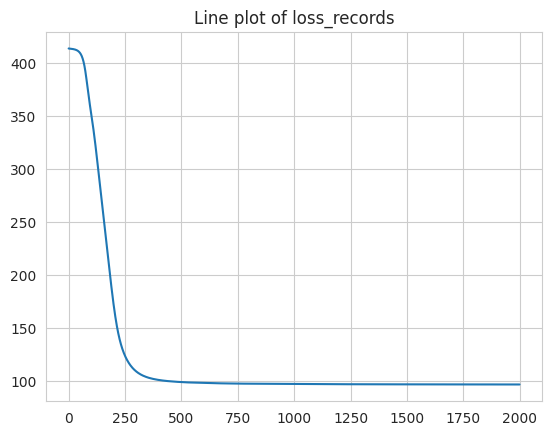

In [11]:
sns.set_style("whitegrid")
sns.lineplot(x=range(epochs), y=loss_records)
plt.title("Line plot of loss_records")
plt.show()

In [16]:
from collections import defaultdict

print("Top loss per word:")

word_loss = defaultdict(float)
probs = {word: forward(word) for word in vocabs}

for center_word, context_word in dataset:
    l = -np.log(probs[center_word][word2idx[context_word]])
    word_loss[center_word] += l

for word, l in sorted(word_loss.items(), key=lambda p: -p[1])[:5]:
    print(f"- {word}: {l}")

Top loss per word:
- learning: 18.388675654988962
- of: 10.777659124357664
- are: 5.563968092453141
- machine: 4.770080627848546
- model: 4.172869597185378


In [13]:
# Inference test


def row_print(title, *args):
    print(f"| {title:>15}  |  {'  '.join(f'{arg:>15}' for arg in args)}  |")

In [14]:
print("Context prediction tests:")
print()

num_ctx = 5

print("-" * (23 + 17 * num_ctx))
row_print("center_word", *(f"ctx_{i}" for i in range(1, num_ctx + 1)))
print("-" * (23 + 17 * num_ctx))

orders = list(range(num_vocabs))

for center_word in random.sample(vocabs, 5):
    probs = forward(center_word)
    orders.sort(key=lambda i: -probs[i])

    row_print(center_word, *(vocabs[i] for i in orders[:num_ctx]))
    row_print("", *(round(100 * probs[i], 1) for i in orders[:num_ctx]))
print("-" * (23 + 17 * num_ctx))

Context prediction tests:

------------------------------------------------------------------------------------------------------------
|     center_word  |            ctx_1            ctx_2            ctx_3            ctx_4            ctx_5  |
------------------------------------------------------------------------------------------------------------
|             can  |            learn           models             data             love          machine  |
|                  |             50.4             49.0              0.1              0.1              0.1  |
|         related  |          closely          popular         networks         learning                i  |
|                  |             99.4              0.2              0.2              0.1              0.0  |
|            part  |               is               of         language          capture         requires  |
|                  |             50.2             49.3              0.1              0.1             